In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
data=pd.read_csv('../data/fake_job_postings.csv')

In [33]:
data.drop(columns=['job_id'],inplace=True)

In [34]:
data.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [35]:
print(data.shape)

(17880, 17)


In [36]:
data['location']=data['location'].fillna('unknown')

In [37]:
data['title_length'] = data['title'].apply(len)

In [38]:
data['has_department'] = data['department'].notna().astype(int)
data = data.drop(columns=['department'])

In [39]:
import re

data['salary_clean'] = data['salary_range'].fillna('Missing')

data['has_salary'] = data['salary_clean'].apply(lambda x: 0 if x in ['Missing', '0-0'] else 1)

def check_if_dirty(val):
    if val == 'Missing':
        return 0
    if val == '0-0' or re.search(r'[a-zA-Z]', str(val)):
        return 1
    return 0

data['is_dirty_salary'] = data['salary_clean'].apply(check_if_dirty)

def extract_min_max(val):
    if val in ['Missing', '0-0'] or re.search(r'[a-zA-Z]', str(val)):
        return -1.0, -1.0
    try:
        parts = str(val).split('-')
        if len(parts) == 2:
            return float(parts[0]), float(parts[1])
    except:
        pass
    return -1.0, -1.0

data['min_salary'], data['max_salary'] = zip(*data['salary_clean'].apply(extract_min_max))

data = data.drop(columns=['salary_range', 'salary_clean'])

In [40]:
data['has_company_profile'] = data['company_profile'].notna().astype(int)
data['profile_length'] = data['company_profile'].fillna('').str.len()
data['company_profile'] = data['company_profile'].fillna('missing')

In [41]:
data['description_length'] = data['description'].fillna('').str.len()
data['description'] = data['description'].fillna('Unknown')

In [42]:
data['has_requirements'] = data['requirements'].notna().astype(int)
data['requirements_length'] = data['requirements'].fillna('').str.len()
data['requirements'] = data['requirements'].fillna('Unknown')

In [43]:
data['has_benefits'] = data['benefits'].notna().astype(int)
data['benefits_length'] = data['benefits'].fillna('').str.len()
data['benefits'] = data['benefits'].fillna('Unknown')

In [44]:
data['employment_type'] = data['employment_type'].fillna('Unknown')

In [45]:
data['has_industry'] = data['industry'].notna().astype(int)
data['industry'] = data['industry'].fillna('Unknown')

In [46]:
data['has_function'] = data['function'].notna().astype(int)
data['function'] = data['function'].fillna('Unknown')

In [47]:
target_columns=['industry','location','function']

In [48]:
ohe_columns=['employment_type']

In [49]:
ordinal_columns=['required_experience','required_education']

In [50]:
TF_IDF_columns=['company_profile','title','description','requirements','benefits']

In [51]:
data.drop_duplicates(inplace=True)

In [52]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['fraudulent'])
y = data['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
experience_map = {
    'Internship': 1,
    'Entry level': 2,
    'Associate': 3,
    'Mid-Senior level': 4,
    'Director': 5,
    'Executive': 6
}
education_map = {
    'Unspecified': 0,
    'Some High School Coursework': 1,
    'High School or equivalent': 2,
    'Vocational': 3,
    'Vocational - HS Diploma': 3,
    'Vocational - Degree': 4,
    'Some College Coursework Completed': 5,
    'Associate Degree': 6,
    'Bachelor\'s Degree': 7,
    'Master\'s Degree': 8,
    'Professional': 9,
    'Doctorate': 10
}

X_train['required_experience'] = X_train['required_experience'].map(experience_map)
X_test['required_experience'] = X_test['required_experience'].map(experience_map)

X_train['required_education'] = X_train['required_education'].map(education_map)
X_test['required_education'] = X_test['required_education'].map(education_map)

X_train['required_experience'] = X_train['required_experience'].fillna(-1)
X_test['required_experience'] = X_test['required_experience'].fillna(-1)

X_train['required_education'] = X_train['required_education'].fillna(-1)
X_test['required_education'] = X_test['required_education'].fillna(-1)

In [54]:
import category_encoders as ce

encoder=ce.TargetEncoder(cols=target_columns,smoothing=10)

X_train = encoder.fit_transform(X_train, y_train)

X_test = encoder.transform(X_test)

In [55]:
import category_encoders as ce

ohe_encoder = ce.OneHotEncoder(cols=['employment_type'], use_cat_names=True)

X_train = ohe_encoder.fit_transform(X_train)

X_test = ohe_encoder.transform(X_test)

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

TF_IDF_columns = ['company_profile', 'title', 'description', 'requirements', 'benefits']

X_train[TF_IDF_columns] = X_train[TF_IDF_columns].fillna('')
X_test[TF_IDF_columns] = X_test[TF_IDF_columns].fillna('')

X_train['combined_text'] = X_train[TF_IDF_columns].apply(lambda x: ' '.join(x), axis=1)
X_test['combined_text'] = X_test[TF_IDF_columns].apply(lambda x: ' '.join(x), axis=1)

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train['combined_text'])

X_test_tfidf = tfidf.transform(X_test['combined_text'])

X_train = X_train.drop(columns=TF_IDF_columns + ['combined_text'])
X_test = X_test.drop(columns=TF_IDF_columns + ['combined_text'])

In [57]:
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score


def evaluate_predictions(y_true, y_pred):
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.colorbar()
    plt.xticks(range(cm.shape[1]), [str(i) for i in range(cm.shape[1])])
    plt.yticks(range(cm.shape[0]), [str(i) for i in range(cm.shape[0])])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black' if cm[i, j] < cm.max() / 2 else 'white')
    plt.tight_layout()
    plt.show()

In [58]:
#import optuna
#from xgboost import XGBClassifier
#from sklearn.model_selection import StratifiedKFold, cross_val_score
#from sklearn.metrics import recall_score, make_scorer
#import numpy as np
#
#fraud_recall_scorer = make_scorer(recall_score, pos_label=1)
#
#def objective(trial):
#    params = {
#        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
#        'max_depth': trial.suggest_int('max_depth', 3, 7),
#        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 10, 150),
#        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#        'random_state': 42
#    }
#    
#    model = XGBClassifier(**params, eval_metric='logloss')
#    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=fraud_recall_scorer, n_jobs=-1)
#    
#    return np.mean(scores)
#
#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=20)
#
#print(study.best_value)
#print(study.best_params)

Precision: 0.1779
Recall: 0.8830
F1 Score: 0.2961
Confusion Matrix:
[[2651  698]
 [  20  151]]


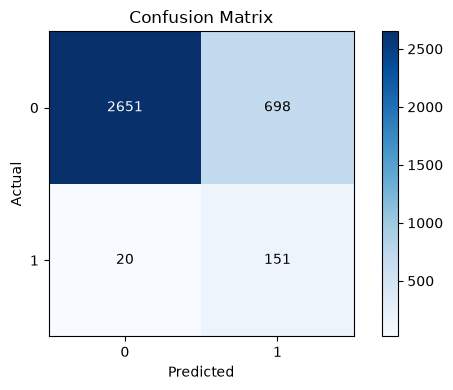

In [59]:
from xgboost import XGBClassifier
model=XGBClassifier(n_estimators=370,
    learning_rate=0.012491787341519192,
    max_depth=3,
    scale_pos_weight=124,
    subsample=0.6860363727116727,
    random_state=42,
    eval_metric='logloss')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
evaluate_predictions(y_test, y_pred)